In [ ]:
!pip -q install pandas pyarrow numpy scikit-learn catboost joblib matplotlib openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor, CatBoostClassifier
from meteostat import Point, Daily
import holidays
from IPython.display import display

In [ ]:
PATH_MAGIC = "/content/drive/MyDrive/BD_Ventas_Magic.csv"
PATH_PAP = "/content/drive/MyDrive/BD_Ventas_Papeleria 1.csv"

OUTPUT_DIR = "/content/drive/MyDrive/V22_FULL_FROM_SCRATCH"
os.makedirs(OUTPUT_DIR, exist_ok=True)

QUITO_LAT = -0.1807
QUITO_LON = -78.4678

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_SIZE = 0.20

In [ ]:
def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    y_true_safe = np.where(np.abs(y_true) < 1e-10, 1e-10, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

    return mae, rmse, mape


def tolerance_accuracy(y_true, y_pred, tol=0.2):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    perc_error = np.abs(y_true - y_pred) / (np.abs(y_true) + 1e-10)
    return (perc_error <= tol).mean() * 100


def train_test_split_ts(df, test_size=0.2):
    split = int(len(df) * (1 - test_size))
    train = df.iloc[:split].copy()
    test = df.iloc[split:].copy()
    return train, test


def temporal_train_valid_split(df, valid_size=0.2):
    split = int(len(df) * (1 - valid_size))
    train_inner = df.iloc[:split].copy()
    valid_inner = df.iloc[split:].copy()
    return train_inner, valid_inner


def custom_score_mape_rmse(y_true, y_pred, mape_weight=0.80):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    y_true_safe = np.where(np.abs(y_true) < 1e-10, 1e-10, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    rmse_norm = (rmse / (np.mean(np.abs(y_true)) + 1e-10)) * 100

    score = mape_weight * mape + (1 - mape_weight) * rmse_norm
    return score, rmse, mape


def optimize_blend_3_v22(y_true, pred1, pred2, pred3, step=0.05, mape_weight=0.80):
    best = {
        "weights": None,
        "score": np.inf,
        "rmse": None,
        "mape": None
    }

    for w1 in np.arange(0.0, 1.01, step):
        for w2 in np.arange(0.0, 1.01 - w1, step):
            w3 = 1.0 - w1 - w2
            if w3 < 0:
                continue

            pred = w1 * pred1 + w2 * pred2 + w3 * pred3
            score, rmse, mape = custom_score_mape_rmse(y_true, pred, mape_weight=mape_weight)

            if score < best["score"]:
                best["weights"] = {
                    "pred_direct": round(float(w1), 2),
                    "pred_ratio": round(float(w2), 2),
                    "pred_global": round(float(w3), 2)
                }
                best["score"] = score
                best["rmse"] = rmse
                best["mape"] = mape

    return best


def optimize_alpha(y_true, pred_a, pred_b, step=0.02, mape_weight=0.78):
    best = {
        "alpha": None,
        "score": np.inf,
        "rmse": None,
        "mape": None
    }

    for alpha in np.arange(0.0, 1.0001, step):
        pred = alpha * pred_a + (1 - alpha) * pred_b
        score, rmse, mape = custom_score_mape_rmse(y_true, pred, mape_weight=mape_weight)

        if score < best["score"]:
            best["alpha"] = round(float(alpha), 2)
            best["score"] = score
            best["rmse"] = rmse
            best["mape"] = mape

    return best


def winsorize_series(s, lower_q=0.02, upper_q=0.98):
    s = s.copy()
    low = s.quantile(lower_q)
    high = s.quantile(upper_q)
    return s.clip(low, high)

In [ ]:
def load_magic_daily(path):
    df = pd.read_csv(path)
    df["fecha_venta"] = pd.to_datetime(df["fecha_venta"])

    daily = (
        df.groupby("fecha_venta")["monto_venta"]
        .sum()
        .reset_index()
        .rename(columns={"monto_venta": "ventas"})
        .sort_values("fecha_venta")
        .reset_index(drop=True)
    )
    return daily


def load_pap_daily(path):
    df = pd.read_csv(path)
    df["fecha_venta"] = pd.to_datetime(df["fecha_venta"])

    daily = (
        df.groupby("fecha_venta")["total"]
        .sum()
        .reset_index()
        .rename(columns={"total": "ventas"})
        .sort_values("fecha_venta")
        .reset_index(drop=True)
    )
    return daily


magic_daily = load_magic_daily(PATH_MAGIC)
pap_daily = load_pap_daily(PATH_PAP)

print("Magic:", magic_daily.shape)
print("Pap:", pap_daily.shape)

display(magic_daily.head())
display(pap_daily.head())

Magic: (176, 2)
Pap: (280, 2)


,fecha_venta,ventas
0,2025-05-31,63.10
1,2025-06-01,35.75
2,2025-06-02,272.40
3,2025-06-03,59.87
4,2025-06-04,194.49


,fecha_venta,ventas
0,2025-02-14,23.30
1,2025-02-15,15.45
2,2025-02-17,5.70
3,2025-02-18,1.56
4,2025-02-19,24.30


In [ ]:
def get_weather_daily(lat, lon, start_date, end_date):
    point = Point(lat, lon)
    weather = Daily(point, start_date, end_date).fetch().reset_index()

    weather = weather.rename(columns={"time": "fecha_venta"})
    weather["fecha_venta"] = pd.to_datetime(weather["fecha_venta"]).dt.tz_localize(None)

    expected_cols = [
        "tavg", "tmin", "tmax", "prcp", "snow",
        "wdir", "wspd", "wpgt", "pres", "tsun"
    ]

    for c in expected_cols:
        if c not in weather.columns:
            weather[c] = np.nan

    return weather[["fecha_venta"] + expected_cols].copy()


global_start = min(magic_daily["fecha_venta"].min(), pap_daily["fecha_venta"].min())
global_end = max(magic_daily["fecha_venta"].max(), pap_daily["fecha_venta"].max())

weather_quito = get_weather_daily(QUITO_LAT, QUITO_LON, global_start, global_end)

print(weather_quito.shape)
display(weather_quito.head())

(336, 11)


,fecha_venta,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2025-02-14,14.6,11.9,18.4,30.3,<NA>,<NA>,8.4,<NA>,1019.0,<NA>
1,2025-02-15,14.4,12.2,17.3,38.5,<NA>,<NA>,9.9,<NA>,1017.2,<NA>
2,2025-02-16,14.3,11.8,18.0,33.2,<NA>,<NA>,9.1,<NA>,1016.6,<NA>
3,2025-02-17,14.0,12.3,15.9,36.6,<NA>,<NA>,9.3,<NA>,1017.1,<NA>
4,2025-02-18,14.4,12.2,17.2,28.8,<NA>,<NA>,9.0,<NA>,1017.0,<NA>


In [ ]:
years = list(range(global_start.year, global_end.year + 1))
ecuador_holidays = holidays.country_holidays("EC", years=years)
print("Feriados:", len(ecuador_holidays))

Feriados: 28


In [ ]:
def add_holidays_and_weather(df_daily, weather_df):
    df = df_daily.merge(weather_df, on="fecha_venta", how="left").copy()

    holiday_dates = set(pd.to_datetime(list(ecuador_holidays.keys())))
    df["is_holiday"] = df["fecha_venta"].dt.normalize().isin(holiday_dates).astype(int)

    df["is_pre_holiday"] = df["fecha_venta"].apply(
        lambda d: int((d + pd.Timedelta(days=1)).normalize() in holiday_dates)
    )
    df["is_post_holiday"] = df["fecha_venta"].apply(
        lambda d: int((d - pd.Timedelta(days=1)).normalize() in holiday_dates)
    )

    return df


magic_base = add_holidays_and_weather(magic_daily, weather_quito)
pap_base = add_holidays_and_weather(pap_daily, weather_quito)

display(magic_base.head())
display(pap_base.head())

,fecha_venta,ventas,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,is_holiday,is_pre_holiday,is_post_holiday
0,2025-05-31,63.10,15.4,12.4,20.9,10.1,<NA>,<NA>,8.3,<NA>,1017.7,<NA>,0,0,0
1,2025-06-01,35.75,15.7,11.9,20.8,0.9,<NA>,<NA>,7.2,<NA>,1017.4,<NA>,0,0,0
2,2025-06-02,272.40,15.6,10.6,21.6,0.0,<NA>,<NA>,7.9,<NA>,1016.9,<NA>,0,0,0
3,2025-06-03,59.87,15.5,11.6,20.8,0.1,<NA>,<NA>,7.4,<NA>,1015.7,<NA>,0,0,0
4,2025-06-04,194.49,15.1,11.5,19.6,3.6,<NA>,<NA>,8.7,<NA>,1016.5,<NA>,0,0,0


,fecha_venta,ventas,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,is_holiday,is_pre_holiday,is_post_holiday
0,2025-02-14,23.30,14.6,11.9,18.4,30.3,<NA>,<NA>,8.4,<NA>,1019.0,<NA>,0,0,0
1,2025-02-15,15.45,14.4,12.2,17.3,38.5,<NA>,<NA>,9.9,<NA>,1017.2,<NA>,0,0,0
2,2025-02-17,5.70,14.0,12.3,15.9,36.6,<NA>,<NA>,9.3,<NA>,1017.1,<NA>,0,0,0
3,2025-02-18,1.56,14.4,12.2,17.2,28.8,<NA>,<NA>,9.0,<NA>,1017.0,<NA>,0,0,0
4,2025-02-19,24.30,14.9,11.9,19.2,11.7,<NA>,<NA>,9.2,<NA>,1017.1,<NA>,0,0,0


In [ ]:
def create_features_v17_base(df):
    df = df.copy().sort_values("fecha_venta").reset_index(drop=True)

    # calendario
    df["dayofweek"] = df["fecha_venta"].dt.dayofweek
    df["day"] = df["fecha_venta"].dt.day
    df["month"] = df["fecha_venta"].dt.month
    df["quarter"] = df["fecha_venta"].dt.quarter
    df["weekofyear"] = df["fecha_venta"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["week_sin"] = np.sin(2 * np.pi * df["weekofyear"] / 52)
    df["week_cos"] = np.cos(2 * np.pi * df["weekofyear"] / 52)

    df["t"] = np.arange(len(df))

    # clima limpio
    weather_cols = ["tavg", "tmin", "tmax", "prcp", "snow", "wdir", "wspd", "wpgt", "pres", "tsun"]
    for c in weather_cols:
        if c not in df.columns:
            df[c] = np.nan

        if df[c].isna().all():
            df[c] = 0
        else:
            df[c] = df[c].interpolate(limit_direction="both")
            df[c] = df[c].fillna(df[c].median())
            df[c] = df[c].fillna(0)

    df["llovio"] = (df["prcp"] > 0).astype(int)
    df["lluvia_fuerte"] = (df["prcp"] > df["prcp"].quantile(0.75)).astype(int)
    df["calor_alto"] = (df["tmax"] > df["tmax"].quantile(0.75)).astype(int)
    df["frio_bajo"] = (df["tmin"] < df["tmin"].quantile(0.25)).astype(int)
    df["llovio_finsemana"] = df["llovio"] * df["is_weekend"]

    for w in [3, 7]:
        df[f"prcp_roll_mean_{w}"] = df["prcp"].rolling(w).mean()
        df[f"tavg_roll_mean_{w}"] = df["tavg"].rolling(w).mean()
        df[f"wspd_roll_mean_{w}"] = df["wspd"].rolling(w).mean()

    # lags
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        df[f"lag{lag}"] = df["ventas"].shift(lag)

    # rolling ventas
    for w in [7, 14, 28]:
        df[f"roll_mean_{w}"] = df["ventas"].rolling(w).mean()
        df[f"roll_std_{w}"] = df["ventas"].rolling(w).std()
        df[f"roll_max_{w}"] = df["ventas"].rolling(w).max()
        df[f"roll_min_{w}"] = df["ventas"].rolling(w).min()
        df[f"roll_median_{w}"] = df["ventas"].rolling(w).median()

    df["ema_7"] = df["ventas"].ewm(span=7, adjust=False).mean()
    df["ema_14"] = df["ventas"].ewm(span=14, adjust=False).mean()

    # cambios
    df["diff1"] = df["ventas"].diff(1)
    df["diff7"] = df["ventas"].diff(7)
    df["growth_1"] = df["ventas"] / (df["lag1"] + 1e-6)
    df["growth_7"] = df["ventas"] / (df["lag7"] + 1e-6)

    # regímenes
    df["weak_demand_regime"] = (
        df["ventas"] <= 0.70 * (df["roll_median_14"] + 1e-6)
    ).astype(int)

    df["high_volatility"] = (
        df["roll_std_7"] > df["roll_std_7"].quantile(0.75)
    ).astype(int)

    df["shock_recent"] = (
        np.abs(df["diff1"]) > np.abs(df["diff1"]).quantile(0.85)
    ).astype(int)

    df["ventas_log"] = np.log1p(df["ventas"])

    df = df.dropna().reset_index(drop=True)
    return df

In [ ]:
magic_feat_v17 = create_features_v17_base(magic_base)
pap_feat_v17 = create_features_v17_base(pap_base)

print("magic_feat_v17:", magic_feat_v17.shape)
print("pap_feat_v17:", pap_feat_v17.shape)

magic_feat_v17: (148, 71)
pap_feat_v17: (252, 71)


In [ ]:
magic_feat_v19 = magic_feat_v17.copy()
pap_feat_v19 = pap_feat_v17.copy()

magic_feat_v19["tenant_id"] = 0
pap_feat_v19["tenant_id"] = 1

print("Magic v19:", magic_feat_v19.shape)
print("Pap v19:", pap_feat_v19.shape)

Magic v19: (148, 72)
Pap v19: (252, 72)


In [ ]:
def add_intermittent_features(df):
    df = df.copy().sort_values("fecha_venta").reset_index(drop=True)

    if "roll_median_7" in df.columns:
        anchor7 = df["roll_median_7"]
    else:
        anchor7 = df["roll_mean_7"]

    if "roll_median_14" in df.columns:
        anchor14 = df["roll_median_14"]
    else:
        anchor14 = df["roll_mean_14"]

    if "ema_7" in df.columns:
        anchor_ema = df["ema_7"]
    else:
        anchor_ema = df["lag1"]

    df["anchor_base"] = 0.50 * anchor7 + 0.30 * anchor14 + 0.20 * anchor_ema
    df["anchor_base"] = df["anchor_base"].replace(0, np.nan)
    df["anchor_base"] = df["anchor_base"].fillna(df["lag1"])
    df["anchor_base"] = df["anchor_base"].fillna(df["ventas"].median())

    df["ventas_log"] = np.log1p(df["ventas"])
    df["ratio_to_anchor"] = df["ventas"] / (df["anchor_base"] + 1e-6)
    df["ratio_to_anchor_log"] = np.log1p(df["ratio_to_anchor"])

    if "roll_median_14" in df.columns:
        base_low = df["roll_median_14"]
    else:
        base_low = df["roll_mean_14"]

    df["low_demand_today"] = (df["ventas"] <= 0.70 * (base_low + 1e-6)).astype(int)
    df["relevant_demand_today"] = 1 - df["low_demand_today"]

    df["lag1_low"] = (df["lag1"] <= 0.70 * (df["anchor_base"] + 1e-6)).astype(int)
    df["lag7_low"] = (df["lag7"] <= 0.70 * (df["anchor_base"] + 1e-6)).astype(int)

    low_hist = df["lag1_low"].fillna(0).astype(int)
    streak = []
    current = 0
    for val in low_hist:
        if val == 1:
            current += 1
        else:
            current = 0
        streak.append(current)
    df["low_demand_streak"] = streak

    threshold_peak = df["ventas"].quantile(0.75)
    last_peak_distance = []
    last_seen = None
    for i, val in enumerate(df["ventas"].shift(1).fillna(0)):
        if last_seen is None:
            last_peak_distance.append(np.nan)
        else:
            last_peak_distance.append(i - last_seen)

        if val >= threshold_peak:
            last_seen = i

    df["days_since_peak"] = pd.Series(last_peak_distance).bfill().fillna(99)

    df["positive_pressure"] = df["lag1"] / (df["anchor_base"] + 1e-6)
    df["positive_pressure_ema"] = df["positive_pressure"].ewm(span=5, adjust=False).mean()

    q01 = df["ratio_to_anchor_log"].quantile(0.01)
    q99 = df["ratio_to_anchor_log"].quantile(0.99)
    df["ratio_to_anchor_log"] = df["ratio_to_anchor_log"].clip(q01, q99)

    return df

In [ ]:
magic_feat_v19 = add_intermittent_features(magic_feat_v19)
pap_feat_v19 = add_intermittent_features(pap_feat_v19)

display(magic_feat_v19[[
    "fecha_venta", "ventas", "anchor_base", "ratio_to_anchor",
    "low_demand_today", "low_demand_streak", "days_since_peak"
]].head())

display(pap_feat_v19[[
    "fecha_venta", "ventas", "anchor_base", "ratio_to_anchor",
    "low_demand_today", "low_demand_streak", "days_since_peak"
]].head())

,fecha_venta,ventas,anchor_base,ratio_to_anchor,low_demand_today,low_demand_streak,days_since_peak
0,2025-07-02,135.68,128.237655,1.058036,0,0,1.0
1,2025-07-03,67.91,117.932616,0.575837,1,0,1.0
2,2025-07-04,147.40,129.094587,1.141798,0,1,1.0
3,2025-07-05,57.68,122.164315,0.472151,1,0,2.0
4,2025-07-07,165.65,131.108487,1.263457,0,1,1.0


,fecha_venta,ventas,anchor_base,ratio_to_anchor,low_demand_today,low_demand_streak,days_since_peak
0,2025-03-28,35.45,32.785032,1.081286,0,0,1.0
1,2025-03-29,25.55,27.035024,0.945070,0,0,1.0
2,2025-03-30,9.90,25.435018,0.389227,1,0,1.0
3,2025-03-31,15.40,24.858764,0.619500,1,1,1.0
4,2025-04-01,107.40,33.976573,3.161001,0,2,1.0


In [ ]:
required_v22 = ["magic_feat_v19", "pap_feat_v19"]
missing_v22 = [v for v in required_v22 if v not in globals()]
print("Faltan:", missing_v22 if missing_v22 else "NINGUNA ✅")

magic_feat_v22 = magic_feat_v19.copy()
pap_feat_v22 = pap_feat_v19.copy()

magic_feat_v22["tenant_id"] = 0
pap_feat_v22["tenant_id"] = 1

print("Magic v22:", magic_feat_v22.shape)
print("Pap v22:", pap_feat_v22.shape)

Faltan: NINGUNA ✅
Magic v22: (148, 83)
Pap v22: (252, 83)


In [ ]:
def add_small_data_targets_v22(df):
    df = df.copy()

    if "anchor_base" not in df.columns:
        if "roll_median_7" in df.columns:
            base7 = df["roll_median_7"]
        else:
            base7 = df["roll_mean_7"]

        if "roll_median_14" in df.columns:
            base14 = df["roll_median_14"]
        else:
            base14 = df["roll_mean_14"]

        if "ema_7" in df.columns:
            base_ema = df["ema_7"]
        else:
            base_ema = df["lag1"]

        df["anchor_base"] = 0.50 * base7 + 0.30 * base14 + 0.20 * base_ema
        df["anchor_base"] = df["anchor_base"].replace(0, np.nan)
        df["anchor_base"] = df["anchor_base"].fillna(df["lag1"])
        df["anchor_base"] = df["anchor_base"].fillna(df["ventas"].median())

    df["ventas_log"] = np.log1p(df["ventas"])

    df["ratio_target"] = df["ventas"] / (df["anchor_base"] + 1e-6)
    df["ratio_target_log"] = np.log1p(df["ratio_target"])

    q01 = df["ratio_target_log"].quantile(0.01)
    q99 = df["ratio_target_log"].quantile(0.99)
    df["ratio_target_log"] = df["ratio_target_log"].clip(q01, q99)

    return df

magic_feat_v22 = add_small_data_targets_v22(magic_feat_v22)
pap_feat_v22 = add_small_data_targets_v22(pap_feat_v22)

In [ ]:
display(magic_feat_v22[["fecha_venta", "ventas", "anchor_base", "ventas_log", "ratio_target_log"]].head())
display(pap_feat_v22[["fecha_venta", "ventas", "anchor_base", "ventas_log", "ratio_target_log"]].head())

,fecha_venta,ventas,anchor_base,ventas_log,ratio_target_log
0,2025-07-02,135.68,128.237655,4.917642,0.721752
1,2025-07-03,67.91,117.932616,4.232801,0.454787
2,2025-07-04,147.40,129.094587,4.999911,0.761646
3,2025-07-05,57.68,122.164315,4.072099,0.386725
4,2025-07-07,165.65,131.108487,5.115896,0.816894


,fecha_venta,ventas,anchor_base,ventas_log,ratio_target_log
0,2025-03-28,35.45,32.785032,3.595941,0.732986
1,2025-03-29,25.55,27.035024,3.279030,0.665298
2,2025-03-30,9.90,25.435018,2.388763,0.328748
3,2025-03-31,15.40,24.858764,2.797281,0.482117
4,2025-04-01,107.40,33.976573,4.685828,1.361707


In [ ]:
magic_train_v22, magic_test_v22 = train_test_split_ts(magic_feat_v22)
pap_train_v22, pap_test_v22 = train_test_split_ts(pap_feat_v22)

print("Magic train/test v22:", magic_train_v22.shape, magic_test_v22.shape)
print("Pap train/test v22:", pap_train_v22.shape, pap_test_v22.shape)

Magic train/test v22: (118, 85) (30, 85)
Pap train/test v22: (201, 85) (51, 85)


In [ ]:
ignore_cols_v22 = [
    "fecha_venta",
    "ventas",
    "ventas_log",
    "ratio_target",
    "ratio_target_log",
    "low_demand_today",
    "relevant_demand_today"
]

features_v22 = [c for c in magic_train_v22.columns if c not in ignore_cols_v22]

print("Total features v22:", len(features_v22))
print(features_v22)

Total features v22: 78
['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'dayofweek', 'day', 'month', 'quarter', 'weekofyear', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 't', 'llovio', 'lluvia_fuerte', 'calor_alto', 'frio_bajo', 'llovio_finsemana', 'prcp_roll_mean_3', 'tavg_roll_mean_3', 'wspd_roll_mean_3', 'prcp_roll_mean_7', 'tavg_roll_mean_7', 'wspd_roll_mean_7', 'lag1', 'lag2', 'lag3', 'lag7', 'lag14', 'lag21', 'lag28', 'roll_mean_7', 'roll_std_7', 'roll_max_7', 'roll_min_7', 'roll_median_7', 'roll_mean_14', 'roll_std_14', 'roll_max_14', 'roll_min_14', 'roll_median_14', 'roll_mean_28', 'roll_std_28', 'roll_max_28', 'roll_min_28', 'roll_median_28', 'ema_7', 'ema_14', 'diff1', 'diff7', 'growth_1', 'growth_7', 'weak_demand_regime', 'high_volatility', 'shock_recent', 'tenant_id', 'anchor_base', 'ratio_to_anchor', 'ratio_to_anchor_log', 'lag1_low', 'lag7_low', 'lo

In [ ]:
def train_direct_small_data_model_v22(train_df, test_df, features, focus="magic"):
    train_inner, valid_inner = temporal_train_valid_split(train_df, valid_size=0.2)

    train_inner = train_inner.copy()
    valid_inner = valid_inner.copy()
    test_df = test_df.copy()

    train_inner["ventas_log_ws"] = winsorize_series(train_inner["ventas_log"], 0.02, 0.98)

    X_train = train_inner[features]
    y_train = train_inner["ventas_log_ws"]

    X_valid = valid_inner[features]
    y_valid = valid_inner["ventas_log"]

    X_test = test_df[features]

    if focus == "magic":
        sample_weights = (
            1 / np.sqrt(train_inner["ventas"] + 1.0)
        ) * (
            1
            + 0.30 * train_inner["shock_recent"].values
            + 0.25 * train_inner["high_volatility"].values
            + 0.20 * train_inner["weak_demand_regime"].values
        )

        model = CatBoostRegressor(
            iterations=1800,
            learning_rate=0.01,
            depth=4,
            l2_leaf_reg=12,
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )
    else:
        sample_weights = (
            1
            + 0.20 * train_inner["is_holiday"].values
            + 0.20 * train_inner["llovio_finsemana"].values
        )

        model = CatBoostRegressor(
            iterations=1800,
            learning_rate=0.01,
            depth=4,
            l2_leaf_reg=10,
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )

    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    pred_valid = np.expm1(model.predict(X_valid))
    pred_test = np.expm1(model.predict(X_test))

    return {
        "model": model,
        "valid_inner": valid_inner.reset_index(drop=True),
        "test_df": test_df.reset_index(drop=True),
        "pred_valid": np.clip(pred_valid, 0, None),
        "pred_test": np.clip(pred_test, 0, None)
    }


def train_ratio_small_data_model_v22(train_df, test_df, features, focus="magic"):
    train_inner, valid_inner = temporal_train_valid_split(train_df, valid_size=0.2)

    train_inner = train_inner.copy()
    valid_inner = valid_inner.copy()
    test_df = test_df.copy()

    train_inner["ratio_target_log_ws"] = winsorize_series(train_inner["ratio_target_log"], 0.02, 0.98)

    X_train = train_inner[features]
    y_train = train_inner["ratio_target_log_ws"]

    X_valid = valid_inner[features]
    X_test = test_df[features]

    if focus == "magic":
        sample_weights = (
            1 / np.sqrt(train_inner["ventas"] + 1.0)
        ) * (
            1
            + 0.25 * train_inner["shock_recent"].values
            + 0.20 * train_inner["weak_demand_regime"].values
        )

        model = CatBoostRegressor(
            iterations=1800,
            learning_rate=0.01,
            depth=4,
            l2_leaf_reg=12,
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )
    else:
        sample_weights = (
            1
            + 0.20 * train_inner["is_holiday"].values
            + 0.20 * train_inner["llovio_finsemana"].values
        )

        model = CatBoostRegressor(
            iterations=1800,
            learning_rate=0.01,
            depth=4,
            l2_leaf_reg=10,
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )

    model.fit(X_train, y_train, sample_weight=sample_weights)

    pred_valid_ratio = np.expm1(model.predict(X_valid))
    pred_test_ratio = np.expm1(model.predict(X_test))

    pred_valid = pred_valid_ratio * valid_inner["anchor_base"].values
    pred_test = pred_test_ratio * test_df["anchor_base"].values

    return {
        "model": model,
        "valid_inner": valid_inner.reset_index(drop=True),
        "test_df": test_df.reset_index(drop=True),
        "pred_valid": np.clip(pred_valid, 0, None),
        "pred_test": np.clip(pred_test, 0, None)
    }


def train_global_small_data_model_v22(magic_train_df, pap_train_df, magic_test_df, pap_test_df, features):
    magic_train_inner, magic_valid_inner = temporal_train_valid_split(magic_train_df, valid_size=0.2)
    pap_train_inner, pap_valid_inner = temporal_train_valid_split(pap_train_df, valid_size=0.2)

    train_global = pd.concat([magic_train_inner, pap_train_inner], axis=0).reset_index(drop=True)
    valid_global = pd.concat([magic_valid_inner, pap_valid_inner], axis=0).reset_index(drop=True)

    train_global["ventas_log_ws"] = winsorize_series(train_global["ventas_log"], 0.02, 0.98)

    X_train = train_global[features]
    y_train = train_global["ventas_log_ws"]

    X_valid = valid_global[features]
    y_valid = valid_global["ventas_log"]

    X_valid_magic = magic_valid_inner[features]
    X_valid_pap = pap_valid_inner[features]

    X_test_magic = magic_test_df[features]
    X_test_pap = pap_test_df[features]

    sample_weights = (
        1
        + 0.20 * train_global["shock_recent"].values
        + 0.20 * train_global["is_holiday"].values
        + 0.15 * train_global["llovio_finsemana"].values
    )

    model = CatBoostRegressor(
        iterations=1800,
        learning_rate=0.01,
        depth=4,
        l2_leaf_reg=12,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    pred_valid_magic = np.expm1(model.predict(X_valid_magic))
    pred_valid_pap = np.expm1(model.predict(X_valid_pap))
    pred_test_magic = np.expm1(model.predict(X_test_magic))
    pred_test_pap = np.expm1(model.predict(X_test_pap))

    return {
        "model": model,
        "pred_valid_magic": np.clip(pred_valid_magic, 0, None),
        "pred_valid_pap": np.clip(pred_valid_pap, 0, None),
        "pred_test_magic": np.clip(pred_test_magic, 0, None),
        "pred_test_pap": np.clip(pred_test_pap, 0, None)
    }


def build_conservative_calibrator_v22(df_valid, y_true, y_pred):
    tmp = df_valid.copy().reset_index(drop=True)
    tmp["y_true"] = np.array(y_true)
    tmp["y_pred"] = np.maximum(np.array(y_pred), 1e-6)

    if "is_weekend" not in tmp.columns:
        tmp["is_weekend"] = (pd.to_datetime(tmp["fecha_venta"]).dt.dayofweek >= 5).astype(int)

    if "is_holiday" not in tmp.columns:
        tmp["is_holiday"] = 0

    tmp["segment"] = (
        tmp["is_weekend"].astype(str) + "_" +
        tmp["is_holiday"].astype(str)
    )

    global_mult = np.median(tmp["y_true"] / tmp["y_pred"])
    global_mult = float(np.clip(global_mult, 0.90, 1.10))

    seg_mult = {}
    for seg, g in tmp.groupby("segment"):
        mult = np.median(g["y_true"] / g["y_pred"])
        mult = float(np.clip(mult, 0.92, 1.08))
        seg_mult[seg] = mult

    return {
        "global_mult": global_mult,
        "seg_mult": seg_mult
    }


def apply_conservative_calibrator_v22(df, pred, calibrator):
    tmp = df.copy().reset_index(drop=True)

    if "is_weekend" not in tmp.columns:
        tmp["is_weekend"] = (pd.to_datetime(tmp["fecha_venta"]).dt.dayofweek >= 5).astype(int)

    if "is_holiday" not in tmp.columns:
        tmp["is_holiday"] = 0

    tmp["segment"] = (
        tmp["is_weekend"].astype(str) + "_" +
        tmp["is_holiday"].astype(str)
    )

    adj = []
    for seg in tmp["segment"]:
        adj.append(calibrator["seg_mult"].get(seg, calibrator["global_mult"]))

    pred = np.array(pred) * np.array(adj)
    return np.clip(pred, 0, None)

In [ ]:
magic_direct_v22 = train_direct_small_data_model_v22(
    magic_train_v22, magic_test_v22, features_v22, focus="magic"
)

magic_ratio_v22 = train_ratio_small_data_model_v22(
    magic_train_v22, magic_test_v22, features_v22, focus="magic"
)

pap_direct_v22 = train_direct_small_data_model_v22(
    pap_train_v22, pap_test_v22, features_v22, focus="pap"
)

pap_ratio_v22 = train_ratio_small_data_model_v22(
    pap_train_v22, pap_test_v22, features_v22, focus="pap"
)

global_v22 = train_global_small_data_model_v22(
    magic_train_v22, pap_train_v22,
    magic_test_v22, pap_test_v22,
    features_v22
)

In [ ]:
best_magic_v22 = optimize_blend_3_v22(
    magic_direct_v22["valid_inner"]["ventas"].values,
    magic_direct_v22["pred_valid"],
    magic_ratio_v22["pred_valid"],
    global_v22["pred_valid_magic"],
    step=0.05,
    mape_weight=0.80
)

best_pap_v22 = optimize_blend_3_v22(
    pap_direct_v22["valid_inner"]["ventas"].values,
    pap_direct_v22["pred_valid"],
    pap_ratio_v22["pred_valid"],
    global_v22["pred_valid_pap"],
    step=0.05,
    mape_weight=0.66
)

print("Best Magic v22:", best_magic_v22)
print("Best Pap v22:", best_pap_v22)

Best Magic v22: {'weights': {'pred_direct': 0.0, 'pred_ratio': 1.0, 'pred_global': 0.0}, 'score': np.float64(9.868502382370611), 'rmse': np.float64(11.409204430075588), 'mape': np.float64(8.700502625876014)}
Best Pap v22: {'weights': {'pred_direct': 0.0, 'pred_ratio': 0.0, 'pred_global': 1.0}, 'score': np.float64(17.92272223839729), 'rmse': np.float64(8.231227142641558), 'mape': np.float64(16.87198003498099)}


In [ ]:
pred_magic_v22_base = (
    best_magic_v22["weights"]["pred_direct"] * magic_direct_v22["pred_test"] +
    best_magic_v22["weights"]["pred_ratio"] * magic_ratio_v22["pred_test"] +
    best_magic_v22["weights"]["pred_global"] * global_v22["pred_test_magic"]
)

pred_pap_v22_base = (
    best_pap_v22["weights"]["pred_direct"] * pap_direct_v22["pred_test"] +
    best_pap_v22["weights"]["pred_ratio"] * pap_ratio_v22["pred_test"] +
    best_pap_v22["weights"]["pred_global"] * global_v22["pred_test_pap"]
)

pred_magic_v22_base = np.clip(pred_magic_v22_base, 0, None)
pred_pap_v22_base = np.clip(pred_pap_v22_base, 0, None)

pred_magic_valid_v22_base = (
    best_magic_v22["weights"]["pred_direct"] * magic_direct_v22["pred_valid"] +
    best_magic_v22["weights"]["pred_ratio"] * magic_ratio_v22["pred_valid"] +
    best_magic_v22["weights"]["pred_global"] * global_v22["pred_valid_magic"]
)

pred_pap_valid_v22_base = (
    best_pap_v22["weights"]["pred_direct"] * pap_direct_v22["pred_valid"] +
    best_pap_v22["weights"]["pred_ratio"] * pap_ratio_v22["pred_valid"] +
    best_pap_v22["weights"]["pred_global"] * global_v22["pred_valid_pap"]
)

magic_calibrator_v22 = build_conservative_calibrator_v22(
    magic_direct_v22["valid_inner"],
    magic_direct_v22["valid_inner"]["ventas"].values,
    pred_magic_valid_v22_base
)

pap_calibrator_v22 = build_conservative_calibrator_v22(
    pap_direct_v22["valid_inner"],
    pap_direct_v22["valid_inner"]["ventas"].values,
    pred_pap_valid_v22_base
)

pred_magic_v22 = apply_conservative_calibrator_v22(
    magic_direct_v22["test_df"],
    pred_magic_v22_base,
    magic_calibrator_v22
)

pred_pap_v22 = apply_conservative_calibrator_v22(
    pap_direct_v22["test_df"],
    pred_pap_v22_base,
    pap_calibrator_v22
)

In [ ]:
mae_v22_magic, rmse_v22_magic, mape_v22_magic = evaluate(
    magic_direct_v22["test_df"]["ventas"], pred_magic_v22
)
acc_mape_v22_magic = 100 - mape_v22_magic
acc20_v22_magic = tolerance_accuracy(
    magic_direct_v22["test_df"]["ventas"], pred_magic_v22, tol=0.20
)

mae_v22_pap, rmse_v22_pap, mape_v22_pap = evaluate(
    pap_direct_v22["test_df"]["ventas"], pred_pap_v22
)
acc_mape_v22_pap = 100 - mape_v22_pap
acc20_v22_pap = tolerance_accuracy(
    pap_direct_v22["test_df"]["ventas"], pred_pap_v22, tol=0.20
)

print("===== V22 SMALL-DATA VOLATILITY MODEL =====")

print("\nMagic World")
print("RMSE:", rmse_v22_magic)
print("MAE:", mae_v22_magic)
print("MAPE:", mape_v22_magic)
print("Accuracy_MAPE:", acc_mape_v22_magic)
print("Accuracy_20%:", acc20_v22_magic)

print("\nPapelería Alfa & Omega")
print("RMSE:", rmse_v22_pap)
print("MAE:", mae_v22_pap)
print("MAPE:", mape_v22_pap)
print("Accuracy_MAPE:", acc_mape_v22_pap)
print("Accuracy_20%:", acc20_v22_pap)

===== V22 SMALL-DATA VOLATILITY MODEL =====

Magic World
RMSE: 55.47305996916292
MAE: 13.857702416277355
MAPE: 16.12046018674291
Accuracy_MAPE: 83.87953981325708
Accuracy_20%: 80.0

Papelería Alfa & Omega
RMSE: 10.253282751285418
MAE: 7.87391450857569
MAPE: 14.874918889763341
Accuracy_MAPE: 85.12508111023666
Accuracy_20%: 76.47058823529412


In [ ]:
magic_imp_v22 = pd.DataFrame({
    "feature": features_v22,
    "importance": magic_direct_v22["model"].get_feature_importance()
}).sort_values("importance", ascending=False).head(25).reset_index(drop=True)

pap_imp_v22 = pd.DataFrame({
    "feature": features_v22,
    "importance": pap_direct_v22["model"].get_feature_importance()
}).sort_values("importance", ascending=False).head(25).reset_index(drop=True)

print("Top variables Magic v22")
display(magic_imp_v22)

print("Top variables Papelería v22")
display(pap_imp_v22)

Top variables Magic v22


,feature,importance
0,ratio_to_anchor_log,25.619212
1,ratio_to_anchor,22.528461
2,weak_demand_regime,13.836346
3,growth_7,7.191045
4,growth_1,4.605196
5,diff1,2.114225
6,anchor_base,1.948182
7,ema_7,1.841045
8,lag1,1.621202
9,roll_median_14,1.532860


Top variables Papelería v22


,feature,importance
0,ratio_to_anchor_log,27.708059
1,ratio_to_anchor,25.259213
2,weak_demand_regime,20.001233
3,ema_7,3.348855
4,growth_1,2.501483
5,anchor_base,1.881930
6,diff1,1.658055
7,growth_7,1.507301
8,ema_14,1.400043
9,diff7,1.283266


In [ ]:
joblib.dump(magic_direct_v22["model"], os.path.join(OUTPUT_DIR, "magic_direct_v22.pkl"))
joblib.dump(magic_ratio_v22["model"], os.path.join(OUTPUT_DIR, "magic_ratio_v22.pkl"))
joblib.dump(pap_direct_v22["model"], os.path.join(OUTPUT_DIR, "pap_direct_v22.pkl"))
joblib.dump(pap_ratio_v22["model"], os.path.join(OUTPUT_DIR, "pap_ratio_v22.pkl"))
joblib.dump(global_v22["model"], os.path.join(OUTPUT_DIR, "global_model_v22.pkl"))

metadata_v22 = {
    "version": "v22_small_data_volatility_model",
    "features_v22": features_v22,
    "best_magic_v22": best_magic_v22,
    "best_pap_v22": best_pap_v22,
    "magic_calibrator_v22": magic_calibrator_v22,
    "pap_calibrator_v22": pap_calibrator_v22,
    "metrics": {
        "magic": {
            "rmse": float(rmse_v22_magic),
            "mae": float(mae_v22_magic),
            "mape": float(mape_v22_magic),
            "accuracy_mape": float(acc_mape_v22_magic),
            "accuracy_20": float(acc20_v22_magic)
        },
        "pap": {
            "rmse": float(rmse_v22_pap),
            "mae": float(mae_v22_pap),
            "mape": float(mape_v22_pap),
            "accuracy_mape": float(acc_mape_v22_pap),
            "accuracy_20": float(acc20_v22_pap)
        }
    }
}

with open(os.path.join(OUTPUT_DIR, "metadata_v22.json"), "w", encoding="utf-8") as f:
    json.dump(metadata_v22, f, indent=2, ensure_ascii=False)

print("Bundle guardado en:", OUTPUT_DIR)

Bundle guardado en: /content/drive/MyDrive/V22_FULL_FROM_SCRATCH


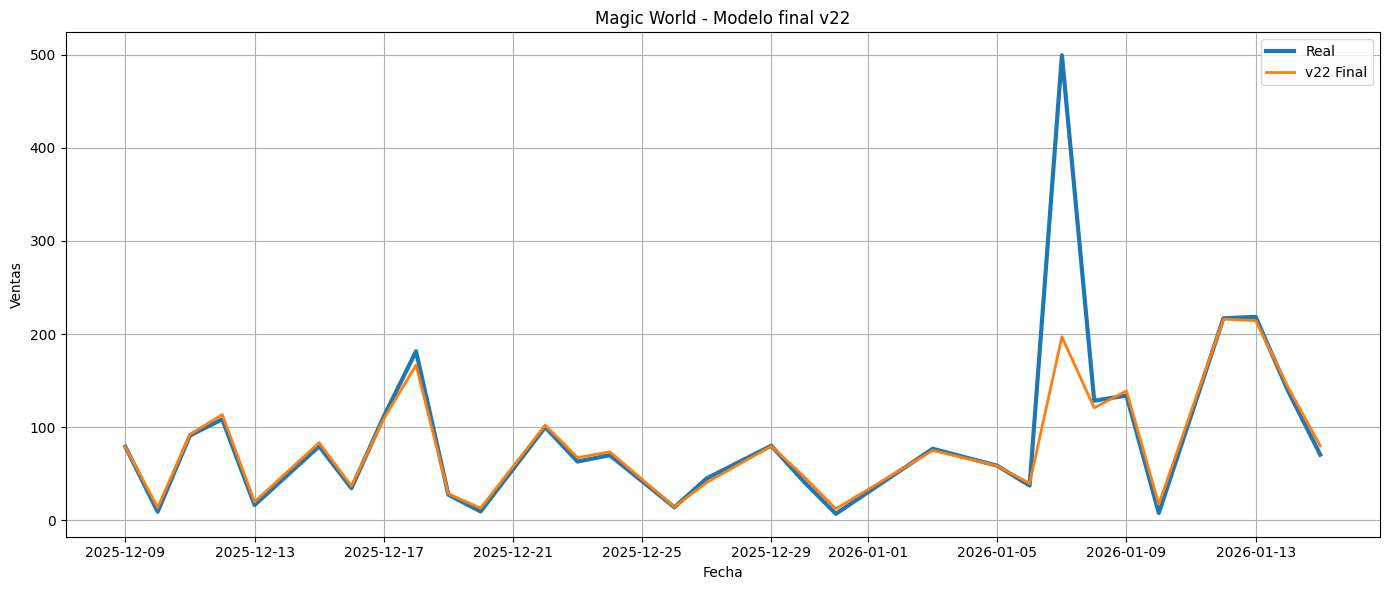

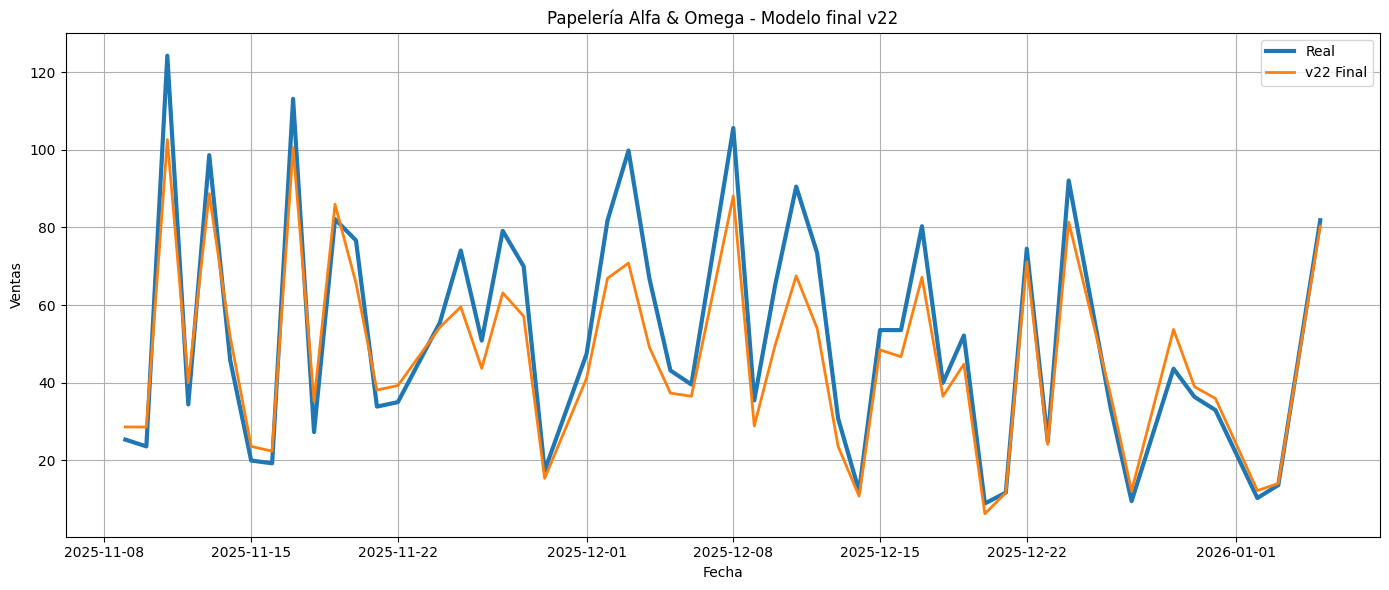

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(magic_direct_v22["test_df"]["fecha_venta"], magic_direct_v22["test_df"]["ventas"], label="Real", linewidth=3)
plt.plot(magic_direct_v22["test_df"]["fecha_venta"], pred_magic_v22, label="v22 Final", linewidth=2)
plt.title("Magic World - Modelo final v22")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(pap_direct_v22["test_df"]["fecha_venta"], pap_direct_v22["test_df"]["ventas"], label="Real", linewidth=3)
plt.plot(pap_direct_v22["test_df"]["fecha_venta"], pred_pap_v22, label="v22 Final", linewidth=2)
plt.title("Papelería Alfa & Omega - Modelo final v22")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

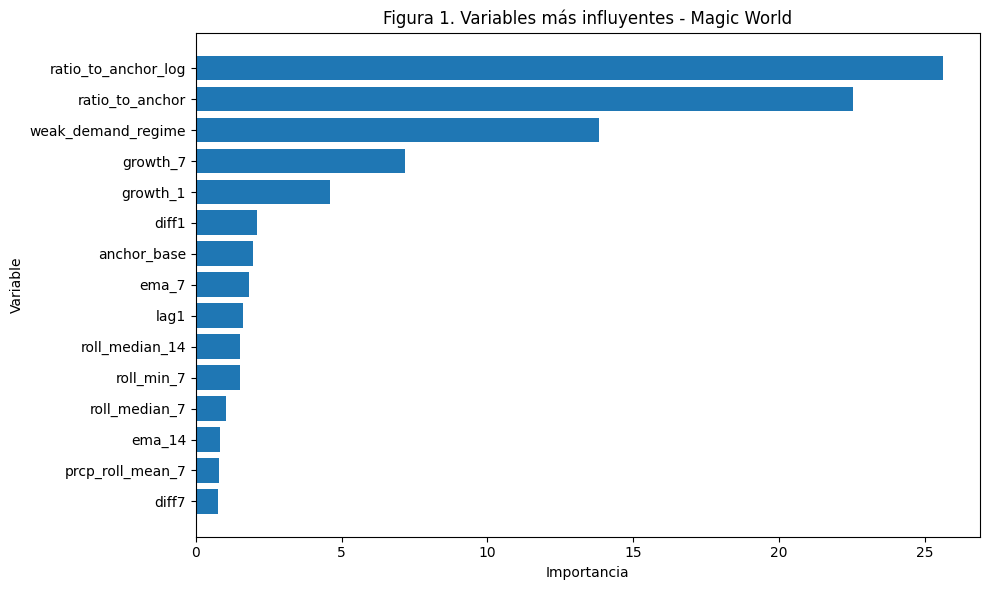

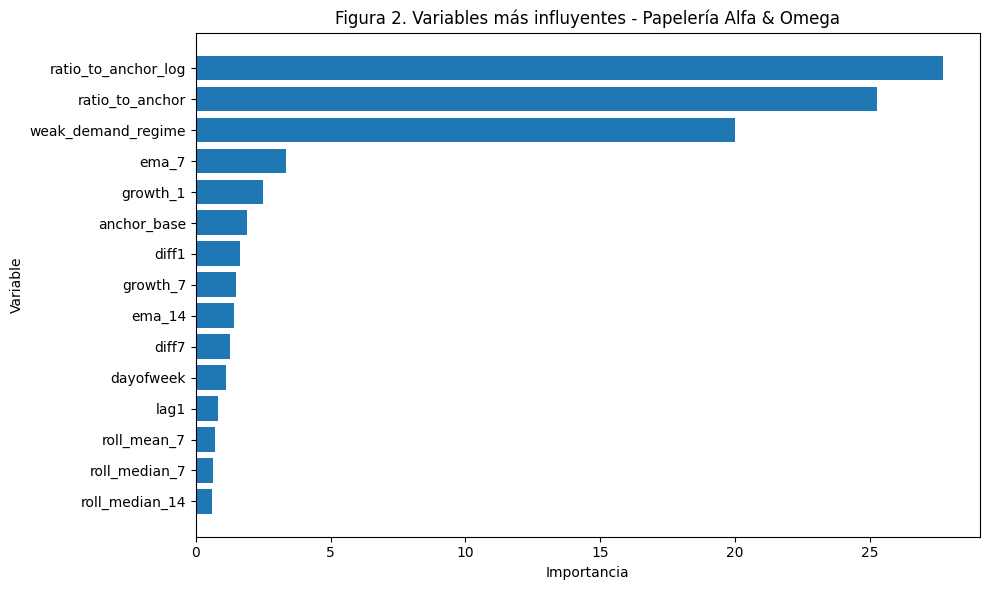

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Importancia Magic
magic_imp_v22 = pd.DataFrame({
    "feature": features_v22,
    "importance": magic_direct_v22["model"].get_feature_importance()
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(magic_imp_v22["feature"][::-1], magic_imp_v22["importance"][::-1])
plt.title("Figura 1. Variables más influyentes - Magic World")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# Importancia Papelería
pap_imp_v22 = pd.DataFrame({
    "feature": features_v22,
    "importance": pap_direct_v22["model"].get_feature_importance()
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(pap_imp_v22["feature"][::-1], pap_imp_v22["importance"][::-1])
plt.title("Figura 2. Variables más influyentes - Papelería Alfa & Omega")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


Forecast exploratorio próximos 7 días — Magic World


,fecha_venta,pred_final
0,2026-01-16,82.19
1,2026-01-17,92.98
2,2026-01-18,99.86
3,2026-01-19,106.58
4,2026-01-20,116.24
5,2026-01-21,122.96
6,2026-01-22,128.77



Forecast exploratorio próximos 7 días — Papelería Alfa & Omega


,fecha_venta,pred_final
0,2026-01-06,81.50
1,2026-01-07,71.25
2,2026-01-08,67.50
3,2026-01-09,58.51
4,2026-01-10,47.59
5,2026-01-11,38.71
6,2026-01-12,35.78


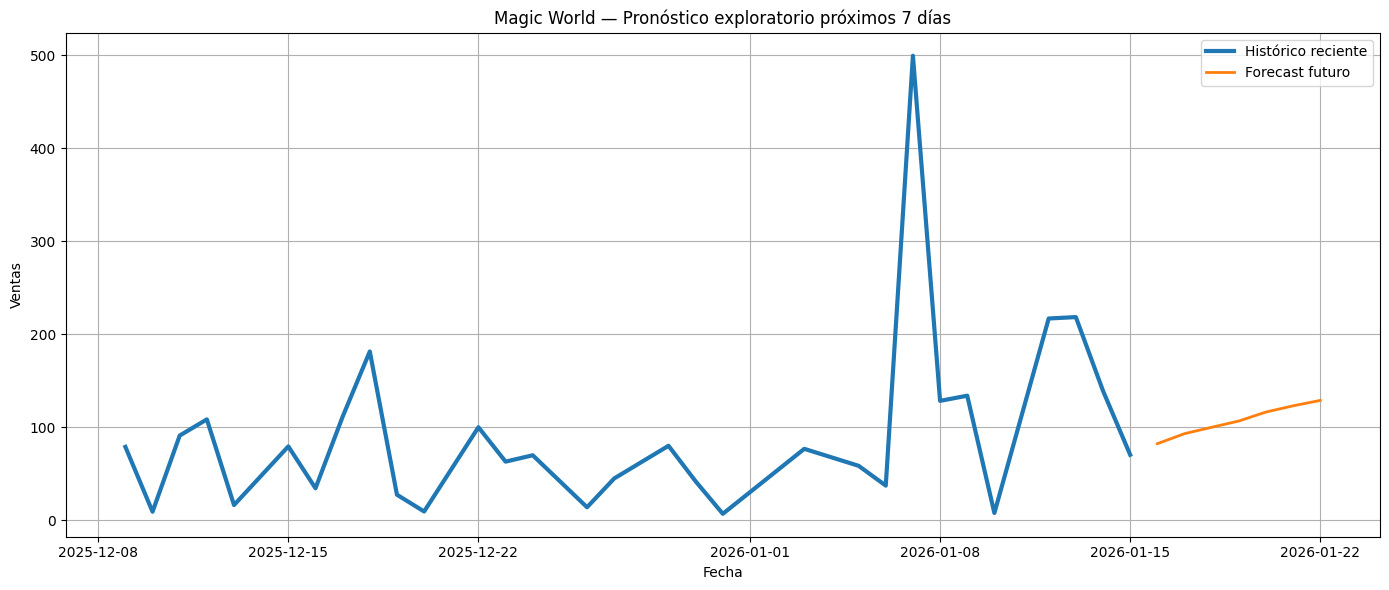

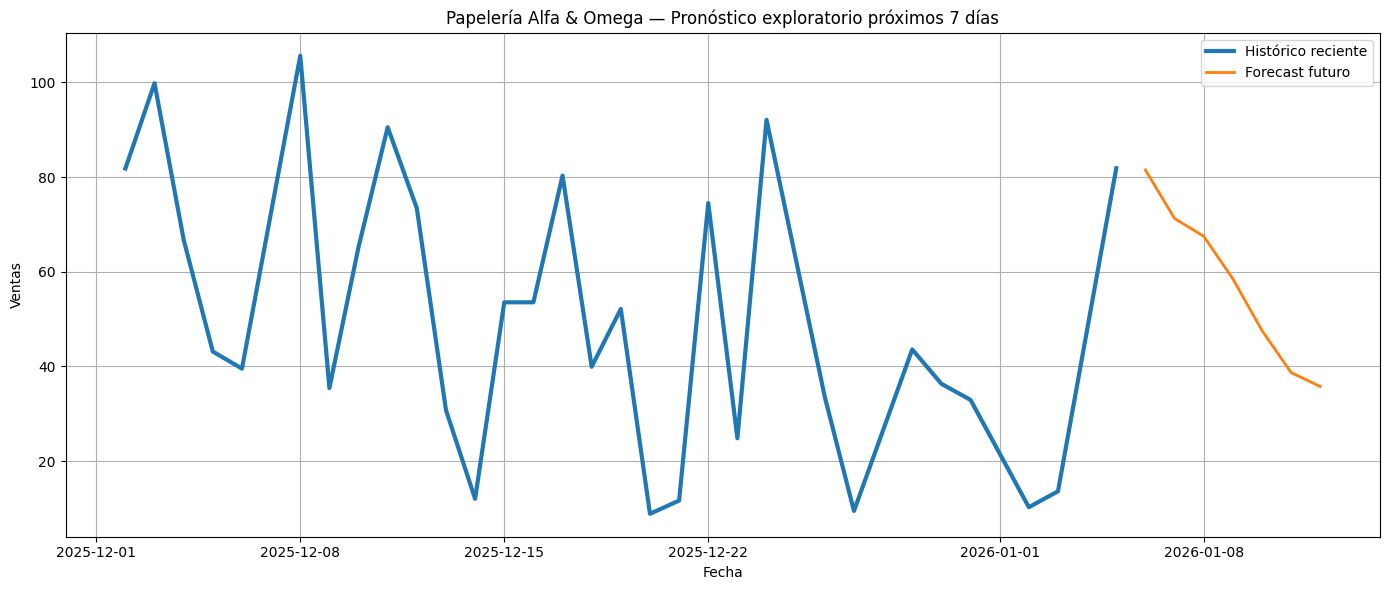


Archivo de pruebas guardado en:
/content/drive/MyDrive/V22_FULL_FROM_SCRATCH/v22_prediction_tests.xlsx

✅ Pruebas finales completadas.
• Validación en test set
• Mejores y peores casos
• Resumen ejecutivo
• Robustez básica
• Forecast exploratorio próximos 7 días


In [ ]:
# ------------------------------------------------------------
# 7) SIMULACIÓN EXPLORATORIA DE PRONÓSTICO FUTURO
# ------------------------------------------------------------
# IMPORTANTE:
# Esta parte es EXPLORATORIA. V22 usa variables como ratio_to_anchor y
# ratio_to_anchor_log, que en entrenamiento dependen de la venta actual.
# Para simular el futuro, aquí usamos proxies basados SOLO en historia pasada.
# Sirve para inspección práctica, pero NO sustituye una versión leak-free
# para despliegue productivo de forecasting puro.

WEATHER_COLS = ["tavg", "tmin", "tmax", "prcp", "snow", "wdir", "wspd", "wpgt", "pres", "tsun"]

def safe_float(x, default=0.0):
    if x is None:
        return float(default)
    try:
        if pd.isna(x):
            return float(default)
    except:
        pass
    try:
        return float(x)
    except:
        return float(default)

def build_weather_profile_by_dow(weather_df):
    tmp = weather_df.copy()
    tmp["fecha_venta"] = pd.to_datetime(tmp["fecha_venta"])

    for c in WEATHER_COLS:
        if c not in tmp.columns:
            tmp[c] = 0.0
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")
        tmp[c] = tmp[c].replace([np.inf, -np.inf], np.nan)

        if tmp[c].isna().all():
            tmp[c] = 0.0
        else:
            tmp[c] = tmp[c].interpolate(limit_direction="both")
            tmp[c] = tmp[c].fillna(tmp[c].median())
            tmp[c] = tmp[c].fillna(0.0)

    tmp["dayofweek"] = tmp["fecha_venta"].dt.dayofweek
    profile = tmp.groupby("dayofweek")[WEATHER_COLS].median().reset_index()

    for c in WEATHER_COLS:
        profile[c] = pd.to_numeric(profile[c], errors="coerce").fillna(0.0)

    return profile

weather_profile_dow = build_weather_profile_by_dow(weather_quito)

def get_future_weather_row(future_date, weather_profile_dow):
    dow = pd.Timestamp(future_date).dayofweek
    row = weather_profile_dow[weather_profile_dow["dayofweek"] == dow]

    if len(row) == 0:
        vals = {c: 0.0 for c in WEATHER_COLS}
    else:
        vals = {}
        for c in WEATHER_COLS:
            vals[c] = safe_float(row.iloc[0][c], 0.0)

    return vals

def compute_ema_from_history(values, span):
    values = [safe_float(v, 0.0) for v in values]
    return pd.Series(values).ewm(span=span, adjust=False).mean().iloc[-1]

def safe_get_lag(values, lag):
    values = [safe_float(v, 0.0) for v in values]
    if len(values) >= lag:
        return float(values[-lag])
    return float(values[0]) if len(values) > 0 else 0.0

def safe_roll(values, window, func):
    values = [safe_float(v, 0.0) for v in values]
    if len(values) == 0:
        return 0.0
    s = pd.Series(values[-window:] if len(values) >= window else values)
    out = func(s)
    return safe_float(out, 0.0)

def build_future_feature_row_v22(history_df, future_date, tenant_id, weather_profile_dow):
    hist = history_df.copy().sort_values("fecha_venta").reset_index(drop=True)
    sales = hist["ventas"].tolist()

    weather_vals = get_future_weather_row(future_date, weather_profile_dow)

    row = {}
    row["fecha_venta"] = pd.Timestamp(future_date)
    row["tenant_id"] = tenant_id

    # calendario
    row["dayofweek"] = row["fecha_venta"].dayofweek
    row["day"] = row["fecha_venta"].day
    row["month"] = row["fecha_venta"].month
    row["quarter"] = row["fecha_venta"].quarter
    row["weekofyear"] = int(row["fecha_venta"].isocalendar().week)
    row["is_weekend"] = int(row["dayofweek"] >= 5)

    row["dow_sin"] = np.sin(2 * np.pi * row["dayofweek"] / 7)
    row["dow_cos"] = np.cos(2 * np.pi * row["dayofweek"] / 7)
    row["month_sin"] = np.sin(2 * np.pi * row["month"] / 12)
    row["month_cos"] = np.cos(2 * np.pi * row["month"] / 12)
    row["week_sin"] = np.sin(2 * np.pi * row["weekofyear"] / 52)
    row["week_cos"] = np.cos(2 * np.pi * row["weekofyear"] / 52)
    row["t"] = len(hist)

    holiday_dates = set(pd.to_datetime(list(ecuador_holidays.keys())))
    row["is_holiday"] = int(row["fecha_venta"].normalize() in holiday_dates)
    row["is_pre_holiday"] = int((row["fecha_venta"] + pd.Timedelta(days=1)).normalize() in holiday_dates)
    row["is_post_holiday"] = int((row["fecha_venta"] - pd.Timedelta(days=1)).normalize() in holiday_dates)

    # clima
    for c in WEATHER_COLS:
        row[c] = safe_float(weather_vals.get(c, 0.0), 0.0)

    # históricos clima seguros
    def safe_hist_col(df, col):
        if col not in df.columns:
            return pd.Series([0.0])
        s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        if s.isna().all():
            return pd.Series([0.0])
        return s.fillna(s.median()).fillna(0.0)

    hist_prcp = safe_hist_col(hist, "prcp")
    hist_tmax = safe_hist_col(hist, "tmax")
    hist_tmin = safe_hist_col(hist, "tmin")

    row["llovio"] = int(row["prcp"] > 0)
    row["lluvia_fuerte"] = int(row["prcp"] > hist_prcp.quantile(0.75))
    row["calor_alto"] = int(row["tmax"] > hist_tmax.quantile(0.75))
    row["frio_bajo"] = int(row["tmin"] < hist_tmin.quantile(0.25))
    row["llovio_finsemana"] = row["llovio"] * row["is_weekend"]

    # rolling clima
    for w in [3, 7]:
        for base_col, out_col in [
            ("prcp", f"prcp_roll_mean_{w}"),
            ("tavg", f"tavg_roll_mean_{w}"),
            ("wspd", f"wspd_roll_mean_{w}")
        ]:
            hist_vals = safe_hist_col(hist, base_col).tolist()
            vals = hist_vals + [row[base_col]]
            row[out_col] = safe_float(pd.Series(vals[-w:]).mean(), 0.0)

    # lags ventas
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        row[f"lag{lag}"] = safe_get_lag(sales, lag)

    # rolling ventas
    for w in [7, 14, 28]:
        row[f"roll_mean_{w}"] = safe_roll(sales, w, pd.Series.mean)
        row[f"roll_std_{w}"] = safe_roll(sales, w, lambda s: s.std(ddof=0) if len(s) > 1 else 0.0)
        row[f"roll_max_{w}"] = safe_roll(sales, w, pd.Series.max)
        row[f"roll_min_{w}"] = safe_roll(sales, w, pd.Series.min)
        row[f"roll_median_{w}"] = safe_roll(sales, w, pd.Series.median)

    # EMA
    row["ema_7"] = safe_float(compute_ema_from_history(sales, 7), 0.0)
    row["ema_14"] = safe_float(compute_ema_from_history(sales, 14), 0.0)

    # cambios usando SOLO pasado
    row["diff1"] = row["lag1"] - row["lag2"]
    row["diff7"] = row["lag1"] - row["lag7"]
    row["growth_1"] = row["lag1"] / (row["lag2"] + 1e-6)
    row["growth_7"] = row["lag1"] / (row["lag7"] + 1e-6)

    # regímenes usando SOLO pasado
    row["weak_demand_regime"] = int(row["lag1"] <= 0.70 * (row["roll_median_14"] + 1e-6))

    hist_roll_std_7 = safe_hist_col(hist, "roll_std_7")
    row["high_volatility"] = int(row["roll_std_7"] > hist_roll_std_7.quantile(0.75))

    hist_diff1_abs = safe_hist_col(hist, "diff1").abs()
    row["shock_recent"] = int(abs(row["diff1"]) > hist_diff1_abs.quantile(0.85))

    # ancla e intermitencia
    row["anchor_base"] = 0.50 * row["roll_median_7"] + 0.30 * row["roll_median_14"] + 0.20 * row["ema_7"]
    if pd.isna(row["anchor_base"]) or row["anchor_base"] <= 0:
        row["anchor_base"] = max(row["lag1"], 1.0)

    row["low_demand_today"] = int(row["lag1"] <= 0.70 * (row["roll_median_14"] + 1e-6))
    row["relevant_demand_today"] = 1 - row["low_demand_today"]
    row["lag1_low"] = int(row["lag1"] <= 0.70 * (row["anchor_base"] + 1e-6))
    row["lag7_low"] = int(row["lag7"] <= 0.70 * (row["anchor_base"] + 1e-6))

    # streak histórica
    if "low_demand_streak" in hist.columns and len(hist) > 0:
        prev_streak = int(safe_float(hist.iloc[-1]["low_demand_streak"], 0))
    else:
        prev_streak = 0
    row["low_demand_streak"] = prev_streak + 1 if row["lag1_low"] == 1 else 0

    if "days_since_peak" in hist.columns and len(hist) > 0:
        prev_days_since_peak = int(safe_float(hist.iloc[-1]["days_since_peak"], 1))
    else:
        prev_days_since_peak = 1

    peak_threshold = safe_float(hist["ventas"].quantile(0.75), 0.0) if len(hist) > 0 else 0.0
    row["days_since_peak"] = 1 if row["lag1"] >= peak_threshold else prev_days_since_peak + 1

    row["positive_pressure"] = row["lag1"] / (row["anchor_base"] + 1e-6)
    prev_pp = hist["positive_pressure"].tolist() if "positive_pressure" in hist.columns else []
    prev_pp = [safe_float(v, 0.0) for v in prev_pp]
    row["positive_pressure_ema"] = pd.Series(prev_pp[-4:] + [row["positive_pressure"]]).ewm(span=5, adjust=False).mean().iloc[-1]

    # PROXY para variables relativas
    proxy_ratio = row["lag1"] / (row["anchor_base"] + 1e-6)
    proxy_ratio = float(np.clip(proxy_ratio, 0, 10))
    row["ratio_to_anchor"] = proxy_ratio
    row["ratio_to_anchor_log"] = np.log1p(proxy_ratio)

    # target placeholders
    row["ventas"] = np.nan
    row["ventas_log"] = np.nan
    row["ratio_target"] = np.nan
    row["ratio_target_log"] = np.nan

    # completar features faltantes
    for c in features_v22:
        if c not in row:
            row[c] = 0.0

    future_df = pd.DataFrame([row])

    for c in future_df.columns:
        if c != "fecha_venta":
            future_df[c] = pd.to_numeric(future_df[c], errors="coerce")

    future_df = future_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return future_df

def apply_single_calibration_v22(future_row_df, pred_value, calibrator):
    tmp = future_row_df.copy()
    if "is_weekend" not in tmp.columns:
        tmp["is_weekend"] = (pd.to_datetime(tmp["fecha_venta"]).dt.dayofweek >= 5).astype(int)
    if "is_holiday" not in tmp.columns:
        tmp["is_holiday"] = 0

    seg = f"{int(tmp.iloc[0]['is_weekend'])}_{int(tmp.iloc[0]['is_holiday'])}"
    mult = calibrator["seg_mult"].get(seg, calibrator["global_mult"])
    return max(pred_value * mult, 0)

def recursive_forecast_v22(
    history_df,
    direct_model,
    ratio_model,
    global_model,
    blend_info,
    calibrator,
    tenant_id,
    horizon=7
):
    hist = history_df.copy().sort_values("fecha_venta").reset_index(drop=True)
    forecasts = []

    last_date = pd.to_datetime(hist["fecha_venta"]).max()

    for h in range(1, horizon + 1):
        future_date = last_date + pd.Timedelta(days=h)
        future_row = build_future_feature_row_v22(hist, future_date, tenant_id, weather_profile_dow)

        X_future = future_row[features_v22].copy()
        X_future = X_future.replace([np.inf, -np.inf], np.nan).fillna(0.0)

        pred_direct = np.expm1(direct_model.predict(X_future))[0]
        pred_ratio_log = np.expm1(ratio_model.predict(X_future))[0]
        pred_ratio = pred_ratio_log * future_row["anchor_base"].values[0]
        pred_global = np.expm1(global_model.predict(X_future))[0]

        pred_base = (
            blend_info["weights"]["pred_direct"] * pred_direct +
            blend_info["weights"]["pred_ratio"] * pred_ratio +
            blend_info["weights"]["pred_global"] * pred_global
        )

        pred_final = apply_single_calibration_v22(future_row, pred_base, calibrator)

        forecasts.append({
            "fecha_venta": future_date,
            "pred_direct": pred_direct,
            "pred_ratio": pred_ratio,
            "pred_global": pred_global,
            "pred_base": pred_base,
            "pred_final": pred_final
        })

        # incorporar predicción al histórico para el siguiente paso
        row_to_append = future_row.copy()
        row_to_append["ventas"] = pred_final
        row_to_append["ventas_log"] = np.log1p(pred_final)
        row_to_append["ratio_target"] = pred_final / (row_to_append["anchor_base"].values[0] + 1e-6)
        row_to_append["ratio_target_log"] = np.log1p(row_to_append["ratio_target"])
        hist = pd.concat([hist, row_to_append], ignore_index=True)

    return pd.DataFrame(forecasts)

# Forecast exploratorio próximos 7 días
magic_forecast_7d_v22 = recursive_forecast_v22(
    history_df=magic_feat_v22,
    direct_model=magic_direct_v22["model"],
    ratio_model=magic_ratio_v22["model"],
    global_model=global_v22["model"],
    blend_info=best_magic_v22,
    calibrator=magic_calibrator_v22,
    tenant_id=0,
    horizon=7
)

pap_forecast_7d_v22 = recursive_forecast_v22(
    history_df=pap_feat_v22,
    direct_model=pap_direct_v22["model"],
    ratio_model=pap_ratio_v22["model"],
    global_model=global_v22["model"],
    blend_info=best_pap_v22,
    calibrator=pap_calibrator_v22,
    tenant_id=1,
    horizon=7
)

print("\nForecast exploratorio próximos 7 días — Magic World")
display(magic_forecast_7d_v22[["fecha_venta", "pred_final"]].round(2))

print("\nForecast exploratorio próximos 7 días — Papelería Alfa & Omega")
display(pap_forecast_7d_v22[["fecha_venta", "pred_final"]].round(2))


# ------------------------------------------------------------
# 8) GRÁFICO DE PRONÓSTICO FUTURO
# ------------------------------------------------------------

def plot_future_forecast(history_df, forecast_df, title, tail=30):
    hist = history_df[["fecha_venta", "ventas"]].copy().tail(tail)

    plt.figure(figsize=(14, 6))
    plt.plot(hist["fecha_venta"], hist["ventas"], label="Histórico reciente", linewidth=3)
    plt.plot(forecast_df["fecha_venta"], forecast_df["pred_final"], label="Forecast futuro", linewidth=2)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Ventas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_future_forecast(
    magic_feat_v22,
    magic_forecast_7d_v22,
    "Magic World — Pronóstico exploratorio próximos 7 días"
)

plot_future_forecast(
    pap_feat_v22,
    pap_forecast_7d_v22,
    "Papelería Alfa & Omega — Pronóstico exploratorio próximos 7 días"
)


# ------------------------------------------------------------
# 9) EXPORTAR RESULTADOS DE PRUEBAS
# ------------------------------------------------------------

test_bundle_path = os.path.join(OUTPUT_DIR, "v22_prediction_tests.xlsx")

with pd.ExcelWriter(test_bundle_path, engine="openpyxl") as writer:
    magic_results_v22.to_excel(writer, sheet_name="magic_test_results", index=False)
    pap_results_v22.to_excel(writer, sheet_name="pap_test_results", index=False)
    executive_summary(magic_results_v22).to_excel(writer, sheet_name="magic_summary", index=False)
    executive_summary(pap_results_v22).to_excel(writer, sheet_name="pap_summary", index=False)
    magic_forecast_7d_v22.to_excel(writer, sheet_name="magic_forecast_7d", index=False)
    pap_forecast_7d_v22.to_excel(writer, sheet_name="pap_forecast_7d", index=False)

print("\nArchivo de pruebas guardado en:")
print(test_bundle_path)

print("\n✅ Pruebas finales completadas.")
print("• Validación en test set")
print("• Mejores y peores casos")
print("• Resumen ejecutivo")
print("• Robustez básica")
print("• Forecast exploratorio próximos 7 días")